# Panda power three bus problem with diagram

In [2]:
import pandapower as pp
import pandapower.plotting as pplot
from pandapower.plotting import simple_plot, pf_res_plotly

# Create empty net
# https://pandapower.readthedocs.io/en/v2.4.0/elements/empty_network.html

net = pp.create_empty_network() 


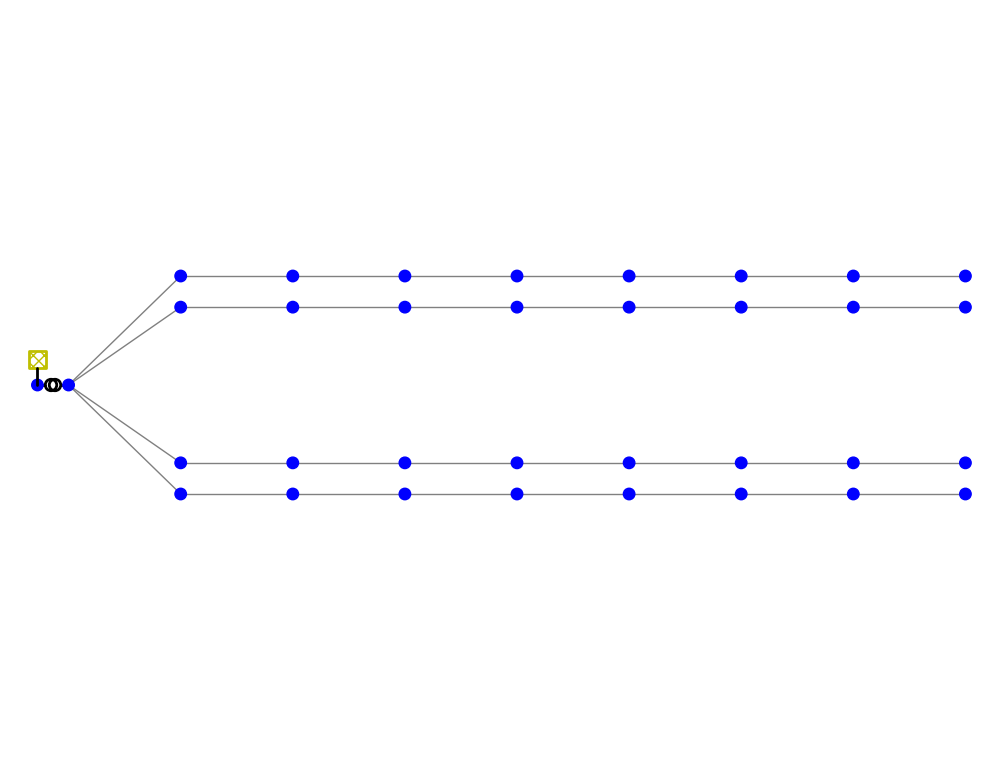

,x,y,coords
0,0.000,0.000,NaN
1,-0.010,0.000,NaN
2,0.036,0.025,NaN
3,0.036,0.035,NaN
4,0.036,-0.035,NaN
5,0.036,-0.025,NaN
6,0.072,0.025,NaN
7,0.072,0.035,NaN
8,0.072,-0.035,NaN
9,0.072,-0.025,NaN


In [3]:
# Create 3 buses, b1,b2,b3 + b0 substation bus
# https://pandapower.readthedocs.io/en/v2.4.0/elements/bus.html
V_nom_kV = 0.240 # Nominal phase voltage in kV
dx = 12/1000 # unit distance x direction (1 block on the graph)
dy = 30/1000 # unit distance y direction (1 block on the graph)

line1 = []
line2 = []
line3 = []
line4 = []

dy_outer = dy-5/1000
dy_inner = dy+5/1000

# define values for line resitances
length_km=3*dx
r_ohm_per_km = 1.15
x_ohm_per_km = 0.135
c_nf_per_km = 1e-9
max_i_ka=1000

# lines between blv and the first outer and inner resitances
initial_length_km_outer = 45/1000
initial_length_km_inner = 39/1000


# Parameter for load
p_mw = 0.006 # constant power load in MW
q_mvar = 2.905932629 # constant reactive power load in MVar


#create 'upper voltage bus and lower voltage bus'
blv = pp.create_bus(net, vn_kv=0.415, name="Bus 0",geodata=(0,0))
bhv = pp.create_bus(net, vn_kv=33.0, name="Bus 1",geodata=(-1/100,0))

# create grid bus and connect it to the upper voltage bus
pp.create_ext_grid(net, bus=bhv, vm_pu=1.02, va_degree=0, name="Grid Connection")


# Create 8 buses for each line
for i in range(1,9):
    line1.append(pp.create_bus(net, vn_kv=V_nom_kV, name="Bus %s"%i,geodata=(i*3*dx,dy_outer)))
    line2.append(pp.create_bus(net, vn_kv=V_nom_kV, name="Bus %s"%i,geodata=(i*3*dx,dy_inner)))
    line3.append(pp.create_bus(net, vn_kv=V_nom_kV, name="Bus %s"%i,geodata=(i*3*dx,dy_inner*(-1))))
    line4.append(pp.create_bus(net, vn_kv=V_nom_kV, name="Bus %s"%i,geodata=(i*3*dx,dy_outer*(-1))))

#create lines between buses within each line using a for loop iterating over the buses from line lists
for i in range(0,7):
    pp.create_line_from_parameters(net,from_bus=line1[i], to_bus=line1[i+1],length_km=length_km, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[((i+1)*3*dx,dy_outer),((i+2)*3*dx,dy_outer)])
    pp.create_line_from_parameters(net,from_bus=line2[i], to_bus=line2[i+1],length_km=length_km, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[((i+1)*3*dx,dy_inner),((i+2)*3*dx,dy_inner)])
    pp.create_line_from_parameters(net,from_bus=line3[i], to_bus=line3[i+1],length_km=length_km, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[((i+1)*3*dx,dy_inner*(-1)),((i+2)*3*dx,dy_inner*(-1))])
    pp.create_line_from_parameters(net,from_bus=line4[i], to_bus=line4[i+1],length_km=length_km, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[((i+1)*3*dx,dy_outer*(-1)),((i+2)*3*dx,dy_outer*(-1))])


# create lines between blv to buses which are the first value from list line1, line2, line3, line4
for i in range(0,1):
    pp.create_line_from_parameters(net,from_bus=blv, to_bus=line1[i],length_km=initial_length_km_outer, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[(0,0),((i+1)*3*dx,dy_outer)])
    pp.create_line_from_parameters(net,from_bus=blv, to_bus=line2[i],length_km=initial_length_km_inner, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[(0,0),((i+1)*3*dx,dy_inner)])
    pp.create_line_from_parameters(net,from_bus=blv, to_bus=line3[i],length_km=initial_length_km_inner, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[(0,0),((i+1)*3*dx,dy_inner*(-1))])
    pp.create_line_from_parameters(net,from_bus=blv, to_bus=line4[i],length_km=initial_length_km_outer, r_ohm_per_km = r_ohm_per_km, x_ohm_per_km = x_ohm_per_km, c_nf_per_km = c_nf_per_km, max_i_ka=max_i_ka,geodata=[(0,0),((i+1)*3*dx,dy_outer*(-1))])
    
# add power load to each bus, with a constant power load of 6MW and a power factor of 0.9
for i in range(0,8):
    pp.create_load(net, bus=line1[i], p_mw=p_mw, q_mvar=q_mvar, name="load")
    pp.create_load(net, bus=line2[i], p_mw=p_mw, q_mvar=q_mvar, name="load")
    pp.create_load(net, bus=line3[i], p_mw=p_mw, q_mvar=q_mvar, name="load")
    pp.create_load(net, bus=line4[i], p_mw=p_mw, q_mvar=q_mvar, name="load")

# parameter for transformer

#add transformer between bhv and blv with the power voltage ratio of 33000:415
pp.create_transformer_from_parameters(net, hv_bus=bhv, lv_bus=blv, sn_mva=1, vn_hv_kv=33, vn_lv_kv=0.415, vkr_percent=0.1, vk_percent=4, pfe_kw=0, i0_percent=0, shift_degree=0, tap_side="hv", tap_neutral=0, tap_min=-2, tap_max=2, tap_step_percent=2.5, tap_step_degree=0, tap_phase_shifter=False, name=None, in_service=True, index=None)
#add grid connection 

#pp.runpp(net)

simple_plot(net)


net.bus_geodata


In [9]:
###### create bus elements

# BUS 0
# Create the link between transformer and bus 1, V=1.06 pu as UK standard is +6-10% Angle =0
# Note: Its called an external grid in PP
# https://pandapower.readthedocs.io/en/v2.4.0/elements/ext_grid.html

pp.create_ext_grid(net, bus=b0, vm_pu=1.06, name="Swing bus")


# BUS 1
# Create a load bus, P=6 kW, Q=2.9 kva #power factor = 0.90 
# https://pandapower.readthedocs.io/en/v2.4.0/elements/load.html

pp.create_load(net, bus=b1, p_mw=0.006, q_mvar=0.0029, name="Load 1")


# BUS 2 
# Create a load bus, P=0MW, Q=45.2 Mvar
# https://pandapower.readthedocs.io/en/v2.4.0/elements/load.html

pp.create_load(net, bus=b2, p_mw=0.006, q_mvar=0.0029, name="Load 2")

#BUS 3
pp.create_load(net, bus=b3, p_mw=0.006, q_mvar=0.0029, name="Load 3")

#BUS 4
pp.create_load(net, bus=b4, p_mw=0.006, q_mvar=0.0029, name="Load 4")

#BUS 5
pp.create_load(net, bus=b5, p_mw=0.006, q_mvar=0.0029, name="Load 5")

#BUS 6


net.load


NameError: name 'b0' is not defined

In [ ]:
## Create lines
#https://pandapower.readthedocs.io/en/v2.4.0/elements/line.html
# NOTE: if x,r in PU then set length_km=Z_base to get from PU values to actual values.

# Calculate Z_Base = V/I = V^2/VI
#VA_nom_MVA =  
#Z_base = (V_nom_kV)**2/VA_nom_MVA
#print ("Z_base = ",Z_base)

# Line 0-1 

pp.create_line_from_parameters(net,from_bus=b0, to_bus=b1,length_km=3*dx+dy, r_ohm_per_km = 1.15, x_ohm_per_km = 0.135, c_nf_per_km = 1e-9, max_i_ka=1000,geodata=[(0,0),(3*dx,dy)])

# Line 1-2

pp.create_line_from_parameters(net,from_bus=b1, to_bus=b2,length_km=3*dx, r_ohm_per_km = 1.15, x_ohm_per_km = 0.135, c_nf_per_km = 1e-9, max_i_ka=1000,geodata=[(3*dx,dy),(6*dx,dy)])

# Line 2-3

pp.create_line_from_parameters(net,from_bus=b2, to_bus=b3,length_km=3*dx, r_ohm_per_km = 1.15, x_ohm_per_km = 0.135, c_nf_per_km = 1e-9, max_i_ka=1000,geodata=[(6*dx,dy),(9*dx,dy)])


net.line

In [ ]:
net.line_geodata

In [ ]:
pp.create_transformer_from_parameters(net, hv_bus=b0, lv_bus=b11, sn_mva=0.00667, vn_hv_kv=33, vn_lv_kv=0.415, vkr_percent=1, vk_percent=14, pfe_kw=1.25, i0_percent=1, shift_degree=0, tap_side="hv", tap_neutral=0, tap_min=-2, tap_max=2, tap_step_percent=2.5, tap_step_degree=0, tap_phase_shifter=False, name=None, in_service=True, index=None, max_loading_percent=1000000000000000, parallel=1, df=1.0, **kwargs)

In [ ]:
# Do a power flow
# https://pandapower.readthedocs.io/en/v2.4.0/powerflow/ac.html

pp.runpp(net, algorithm='gs', numba=False);

In [5]:
# Save the network to a json file
# https://pandapower.readthedocs.io/en/v2.4.0/file_io.html

pp.to_json(net,"ThreeBusPlot.json")

In [6]:
# View results on the busses
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar


In [7]:
# View results on the lines
net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent


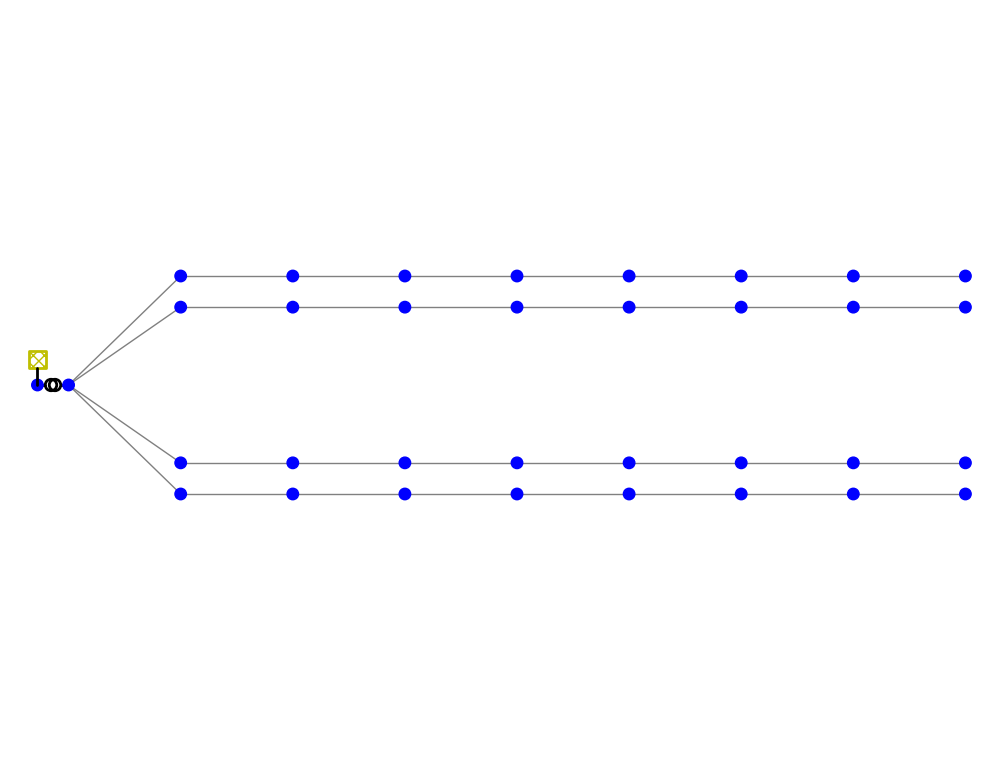

<Axes: >

In [8]:
# Simple plotting
# https://pandapower.readthedocs.io/en/v2.4.0/plotting.html
# Also look at https://www.youtube.com/watch?v=O99JNoUytAc

pplot.simple_plot(net)